## Analysis of capabilities of Sec-certs

This notebook showcases the capabilities and contents that can be extracted from Sec-Certs in context of OpenSSL

#### Important imports

In [1]:
from sec_certs.dataset.cc import CCDataset
from sec_certs.dataset.fips import FIPSDataset
import pandas as pd
from src.utils import get_cc_library_mentions, get_fips_library_mentions 
import matplotlib.pyplot as plt
import re


#### Download datasets
Download the most recent datasets for Common Criteria (CC) and FIPS 140 from the Sec-Certs online repository

In [2]:
print("Downloading CC dataset")

cc_dataset = CCDataset.from_web()

print(f"Downloaded {len(cc_dataset)} CC certificates")
print("Saving dataset")

cc_dataset.to_json("./datasets/CC_dataset.json")

print("Dataset saved to ./datasets/CC_dataset.json")

print("Dowloading FIPS dataset")

fips_dataset = FIPSDataset.from_web()

print(f"Downloaded {len(fips_dataset)} FIPS 140 certificates")
print("Saving dataset")

fips_dataset.to_json("./datasets/FIPS_dataset.json")

print("Dataset saved to ./datasets/FIPS_dataset.json")

Downloading: CCDataset:   0%|          | 0.00/193M [00:00<?, ?B/s]

Dataset was created with sec-certs version 0.3.2.post1.dev139+g8ab79f0c7 (older than your version 0.4.1). To install the matching version: pip install sec-certs==0.3.2.post1.dev139+g8ab79f0c7


Downloaded 6729 CC certificates
Saving dataset
Dataset saved to ./datasets/CC_dataset.json
Dowloading FIPS dataset


Downloading: FIPSDataset:   0%|          | 0.00/69.5M [00:00<?, ?B/s]

Dataset was created with sec-certs version 0.3.2.post1.dev139+g8ab79f0c7 (older than your version 0.4.1). To install the matching version: pip install sec-certs==0.3.2.post1.dev139+g8ab79f0c7


Downloaded 5246 FIPS 140 certificates
Saving dataset
Dataset saved to ./datasets/FIPS_dataset.json


#### Import downloaded datasets

In [3]:
print("Loading datasets from JSON")
cc_dataset = CCDataset.from_json("./datasets/CC_dataset.json")
fips_dataset = FIPSDataset.from_json("./datasets/FIPS_dataset.json")
print(f"Loaded {len(cc_dataset)} CC certificates from JSON")
print(f"Loaded {len(fips_dataset)} FIPS 140 certificates from JSON")

Loading datasets from JSON


Dataset was created with sec-certs version 0.3.2.post1.dev139+g8ab79f0c7 (older than your version 0.4.1). To install the matching version: pip install sec-certs==0.3.2.post1.dev139+g8ab79f0c7
Dataset was created with sec-certs version 0.3.2.post1.dev139+g8ab79f0c7 (older than your version 0.4.1). To install the matching version: pip install sec-certs==0.3.2.post1.dev139+g8ab79f0c7


Loaded 6729 CC certificates from JSON
Loaded 5246 FIPS 140 certificates from JSON


### Convert dataset to pandas



In [4]:
cc_pandas = cc_dataset.to_pandas()
fips_pandas = fips_dataset.to_pandas()

plt.rcParams.update({
    "font.size": 14,          # all text
    "axes.titlesize": 16,     # title
    "axes.labelsize": 14,     # axis labels
    "xtick.labelsize": 12,    # tick labels
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})



#### Create dataframes of CC cetrificates containing OpenSSL or alternatives

In [5]:
openssl_df_cc = get_cc_library_mentions(cc_dataset, "OpenSSL")
boringssl_df_cc = get_cc_library_mentions(cc_dataset, "BoringSSL")
wolfssl_df_cc = get_cc_library_mentions(cc_dataset, "wolfSSL")
nss_df_cc = get_cc_library_mentions(cc_dataset, "NSS")
bouncy_castle_df_cc = get_cc_library_mentions(cc_dataset, "BouncyCastle")
libgcrypt_df_cc = get_cc_library_mentions(cc_dataset, "libgcrypt")

combined_cc_df = pd.concat([openssl_df_cc, boringssl_df_cc, wolfssl_df_cc, nss_df_cc, bouncy_castle_df_cc, libgcrypt_df_cc], ignore_index=True)

print(f"Number of certificates with OpenSSL in library {len(openssl_df_cc)}")
print(f"Number of certificates with Libgcrypt in library {len(libgcrypt_df_cc)}")
print(f"Number of certificates with BoringSSL in library {len(boringssl_df_cc)}")
print(f"Number of certificates with WolfSSL in library {len(wolfssl_df_cc)}")
print(f"Number of certificates with NSS in library {len(nss_df_cc)}")
print(f"Number of certificates with BouncyCastle in library {len(bouncy_castle_df_cc)}")

print(f"Number of certificates with any of the libraries: {len(combined_cc_df)}")





Number of certificates with OpenSSL in library 1145
Number of certificates with Libgcrypt in library 47
Number of certificates with BoringSSL in library 86
Number of certificates with WolfSSL in library 10
Number of certificates with NSS in library 76
Number of certificates with BouncyCastle in library 34
Number of certificates with any of the libraries: 1398


#### Create dataframes of FIPS certificates containing OpenSSL or alternatives

In [6]:
openssl_df_fips = get_fips_library_mentions(fips_dataset, "OpenSSL")
boringssl_df_fips = get_fips_library_mentions(fips_dataset, "BoringSSL")
wolfssl_df_fips = get_fips_library_mentions(fips_dataset, "wolfSSL")
nss_df_fips = get_fips_library_mentions(fips_dataset, "NSS")
bouncy_castle_df_fips = get_fips_library_mentions(fips_dataset, "BouncyCastle")
libgcrypt_df_fips = get_fips_library_mentions(fips_dataset, "libgcrypt")

combined_fips_df = pd.concat([openssl_df_fips, boringssl_df_fips, wolfssl_df_fips, nss_df_fips, bouncy_castle_df_fips, libgcrypt_df_fips], ignore_index=True)

print(f"Number of certificates with OpenSSL in library {len(openssl_df_fips)}")
print(f"Number of certificates with Libgcrypt in library {len(libgcrypt_df_fips)}")
print(f"Number of certificates with BoringSSL in library {len(boringssl_df_fips)}")
print(f"Number of certificates with WolfSSL in library {len(wolfssl_df_fips)}")
print(f"Number of certificates with NSS in library {len(nss_df_fips)}")
print(f"Number of certificates with BouncyCastle in library {len(bouncy_castle_df_fips)}")

print(f"Number of certificates with any of the libraries: {len(combined_fips_df)}")

Number of certificates with OpenSSL in library 919
Number of certificates with Libgcrypt in library 41
Number of certificates with BoringSSL in library 60
Number of certificates with WolfSSL in library 15
Number of certificates with NSS in library 111
Number of certificates with BouncyCastle in library 27
Number of certificates with any of the libraries: 1173


#### Total certificates for each library

              CC Count  FIPS Count
Library                           
BoringSSL           86          60
BouncyCastle        34          27
NSS                 76         111
OpenSSL           1145         919
libgcrypt           47          41
wolfSSL             10          15


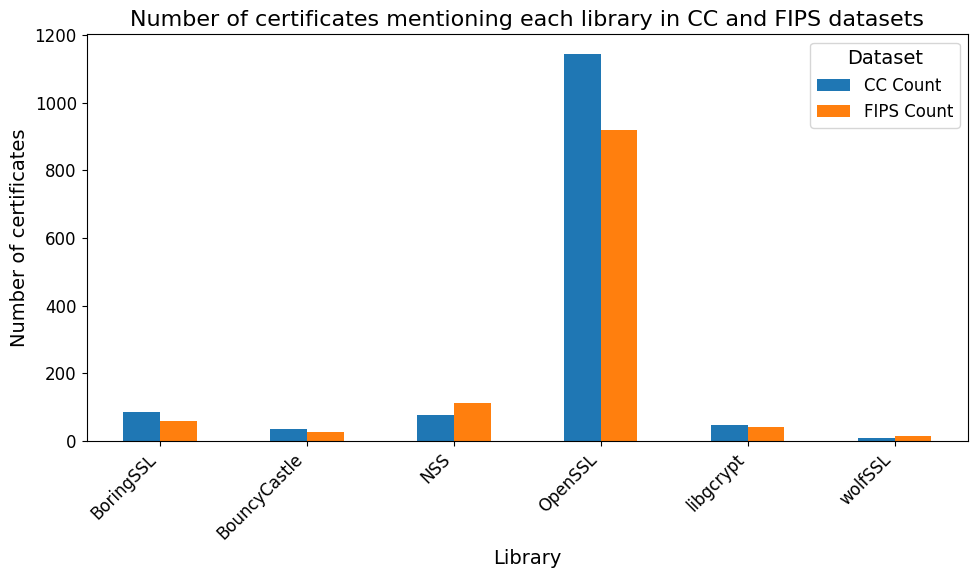

In [8]:
df_total_cc = combined_cc_df.groupby("Library").size().reset_index(name="CC Count")
df_total_fips = combined_fips_df.groupby("Library").size().reset_index(name="FIPS Count")

df_total_combined = pd.merge(
    df_total_cc,
    df_total_fips,
    on="Library",
    how="outer"
).fillna(0)

df_total_combined = df_total_combined.set_index("Library")

ax = df_total_combined.plot(kind="bar", figsize=(10, 6))

plt.title("Number of certificates mentioning each library in CC and FIPS datasets")
plt.xlabel("Library")
plt.ylabel("Number of certificates")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")
plt.tight_layout()
plt.savefig("img/library_mentions_comparison.png")

print(df_total_combined)


#### FIPS certificates per standard over years

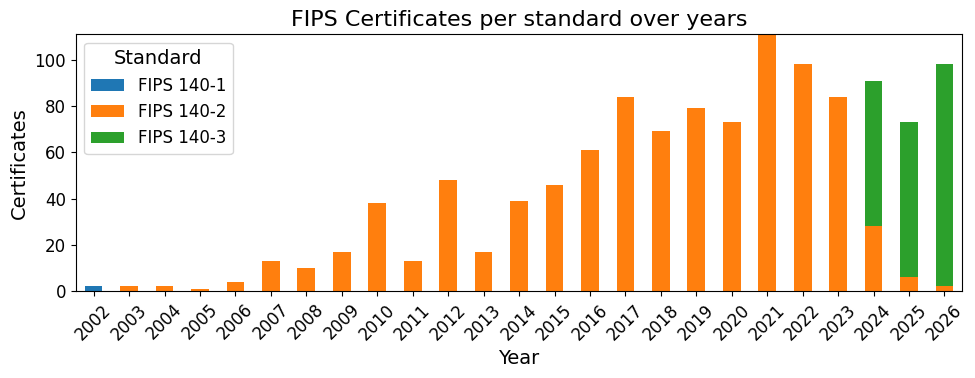

<Figure size 640x480 with 0 Axes>

In [9]:
df_yearly_std = (
    combined_fips_df
    .groupby(['Year', 'Standard'])['Manufacturer']
    .count()
    .unstack(fill_value=0)   
)


ax = df_yearly_std.plot(kind='bar', figsize=(10, 4), stacked=True)
plt.title('FIPS Certificates per standard over years')
plt.ylabel('Certificates')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.legend(title='Standard')
plt.tight_layout()
plt.show()
plt.savefig("img/fips_certificates_per_standard_over_years.png")

#### FIPS certificates by security

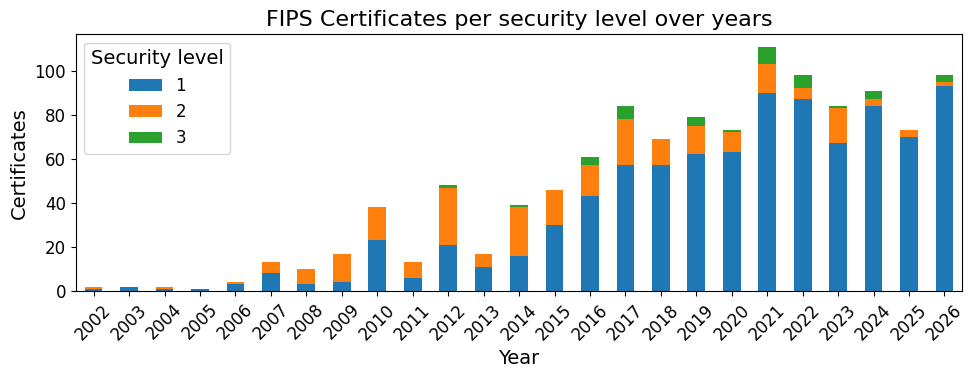

<Figure size 640x480 with 0 Axes>

In [10]:
df_yearly_std = (
    combined_fips_df
    .groupby(['Year', 'Level'])['Manufacturer']  
    .count()
    .unstack(fill_value=0)
)

ax = df_yearly_std.plot(kind='bar', figsize=(10, 4), stacked=True)
plt.title('FIPS Certificates per security level over years')
plt.ylabel('Certificates')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.legend(title='Security level')
plt.tight_layout()
plt.show()
plt.savefig("img/fips_certificates_per_security_level_over_years.png")

#### CC certificates by assurance level

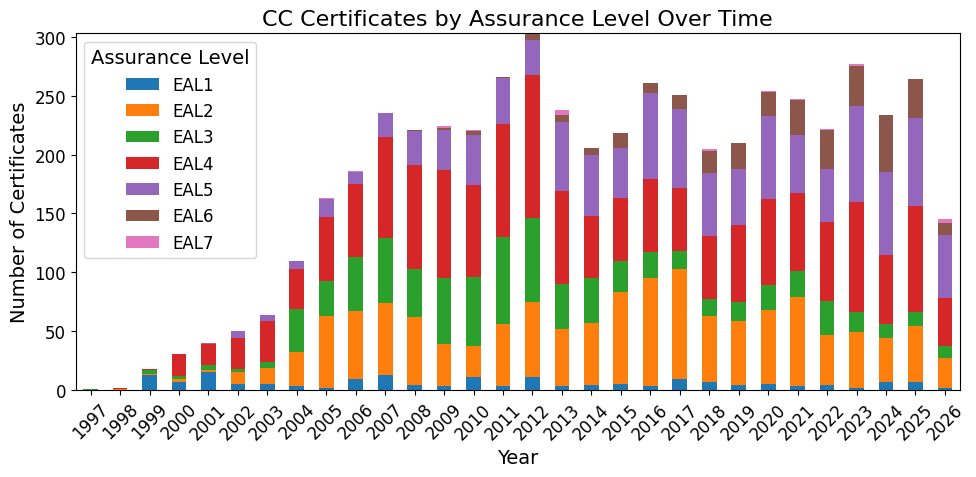

<Figure size 640x480 with 0 Axes>

In [11]:
rows = []

for cert in cc_dataset:
    not_valid_before = cert.not_valid_before
    elements = cert.security_level

    eal_raw = next((el for el in elements if el.startswith("EAL")), None)
    if not_valid_before is None or eal_raw is None:
        continue  # skip certs without date or EAL

    m = re.match(r"(EAL[1-7])", eal_raw)
    if not m:
        continue
    eal_norm = m.group(1)
    year = pd.to_datetime(not_valid_before).year
    rows.append({"Year": year, "EAL": eal_norm})

df = pd.DataFrame(rows)

df_counts = (
    df.groupby(["Year", "EAL"])
      .size()
      .unstack(fill_value=0)       
      .sort_index()               
)


ax = df_counts.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("CC Certificates by Assurance Level Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Certificates")
plt.legend(title="Assurance Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig("img/cc_certificates_per_eal_over_years.png")


#### Manufacturers mentioning OpenSSL in CC and FIPS certificates

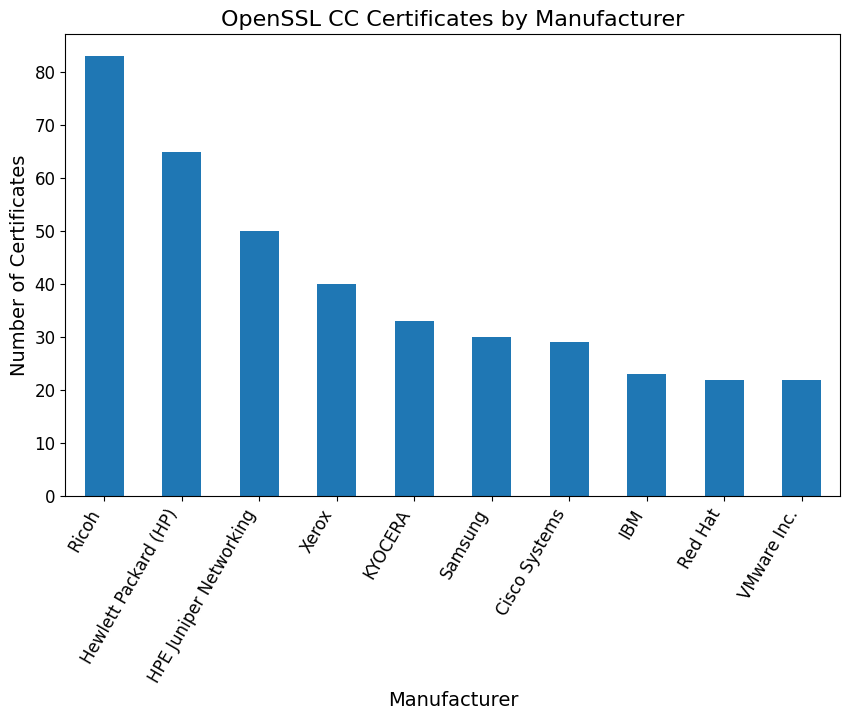

<Figure size 640x480 with 0 Axes>

In [12]:
df_manufacturer_counts = openssl_df_cc['Manufacturer'].value_counts()
df_manufacturer_counts.head(10).plot(kind='bar', figsize=(10, 6))
plt.title('OpenSSL CC Certificates by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Certificates')
plt.xticks(rotation=60, ha='right')  
plt.show()
plt.savefig("img/openssl_cc_certificates_by_manufacturer.png")

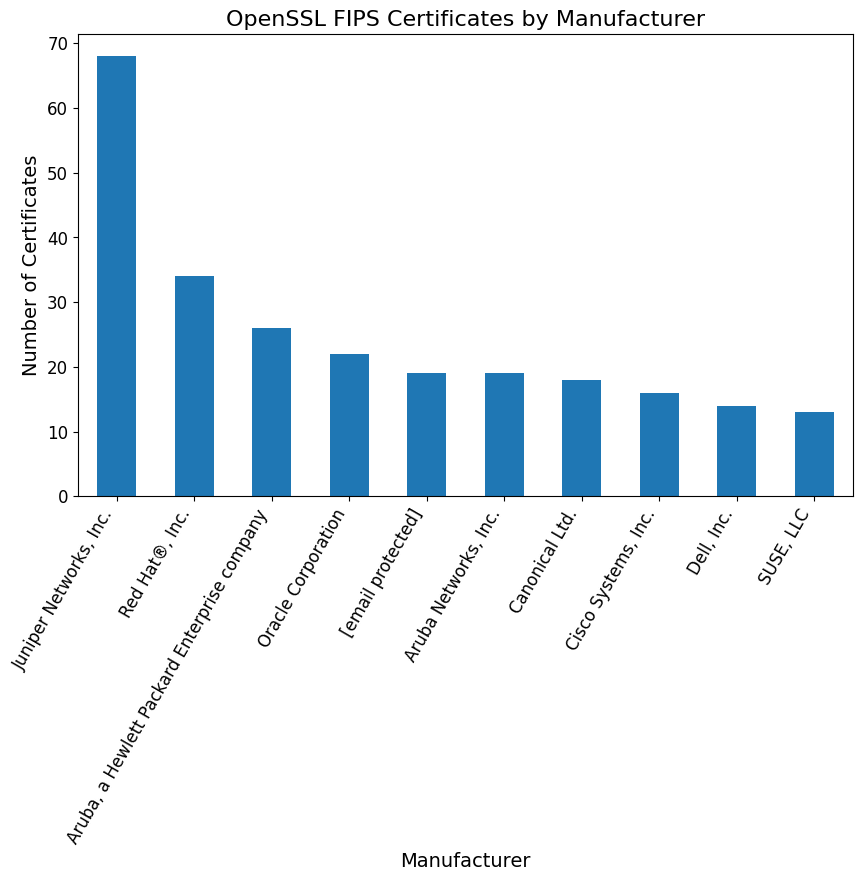

<Figure size 640x480 with 0 Axes>

In [13]:
df_manufacturer_counts = openssl_df_fips['Manufacturer'].value_counts()
df_manufacturer_counts.head(10).plot(kind='bar', figsize=(10, 6))
plt.title('OpenSSL FIPS Certificates by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Certificates')
plt.xticks(rotation=60, ha='right')  
plt.show()
plt.savefig("img/openssl_fips_certificates_by_manufacturer.png")

#### Total CC certificates per category

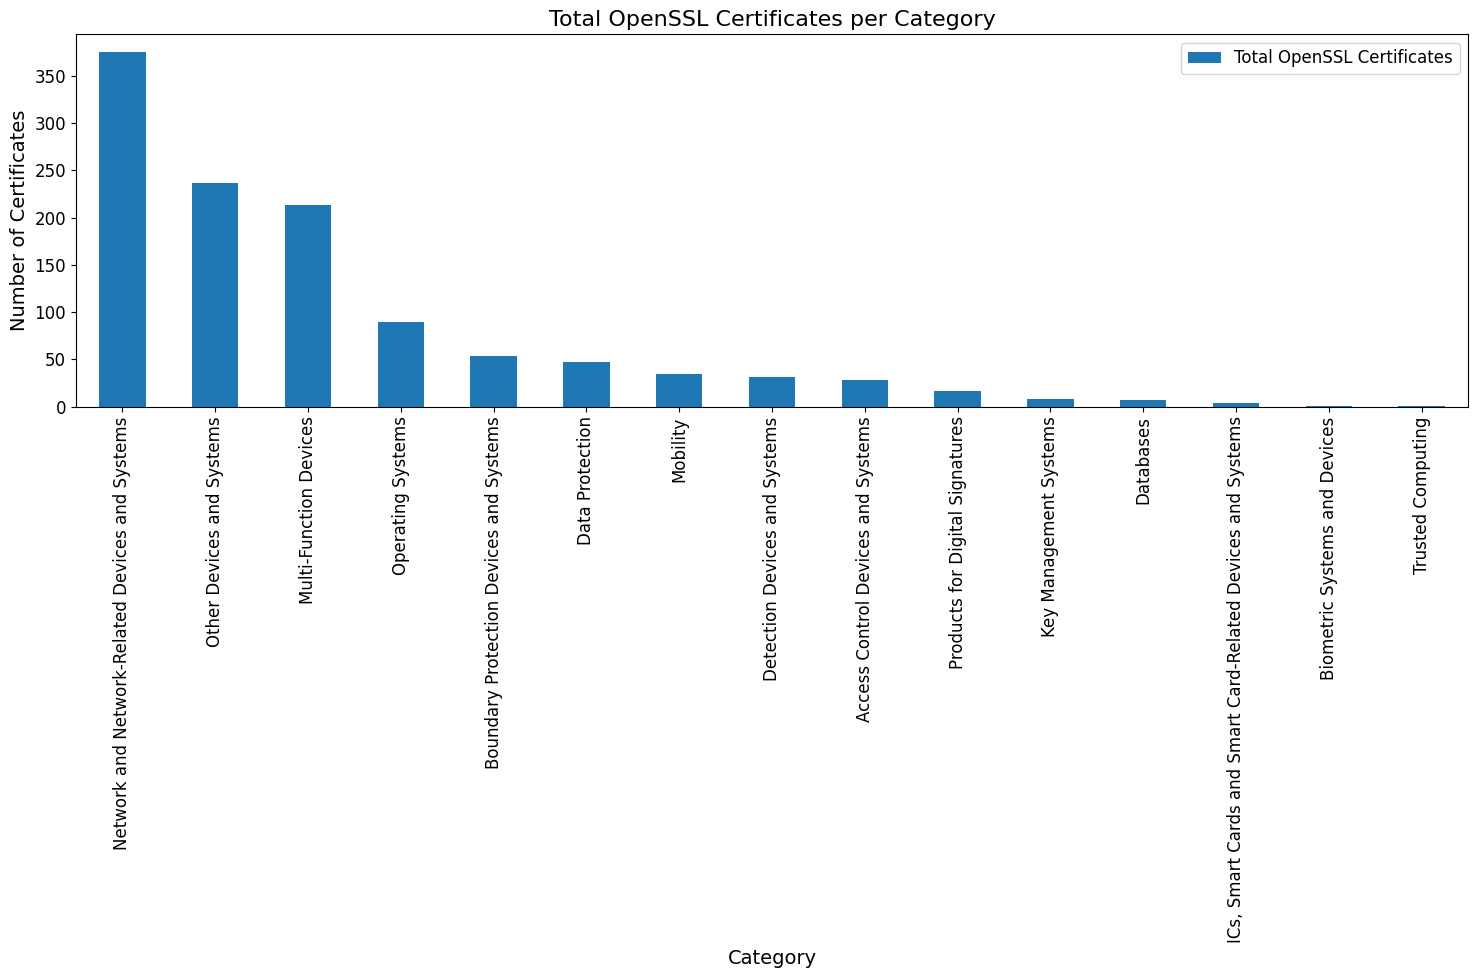

<Figure size 640x480 with 0 Axes>

In [14]:
total_per_category = openssl_df_cc['Category'].value_counts().sort_values(ascending=False)

df_combined = pd.DataFrame({ 'Total OpenSSL Certificates': total_per_category })


ax = df_combined.plot(kind='bar', figsize=(15, 10))
plt.title('Total OpenSSL Certificates per Category')
plt.ylabel('Number of Certificates')
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()
plt.savefig("img/openssl_cc_certificates_by_category.png")


#### Total FIPS certificates per category

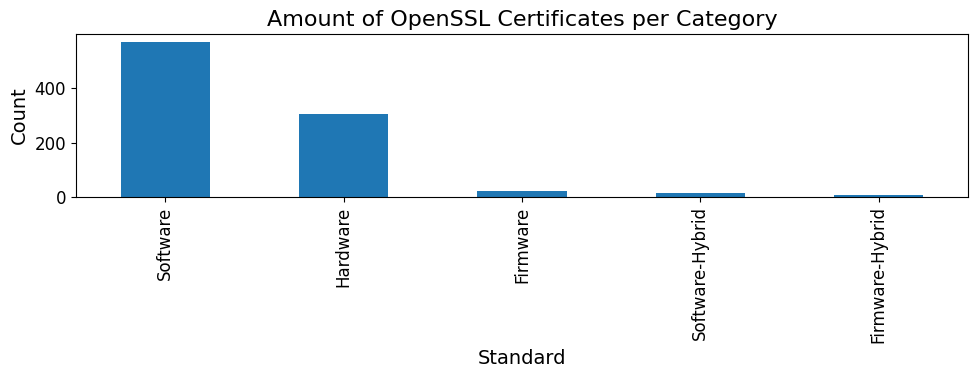

<Figure size 640x480 with 0 Axes>

In [15]:
df_yearly_all = openssl_df_fips.groupby('ModuleType')['ModuleType'].count().sort_values(ascending=False)

# Bar plot
df_yearly_all.plot(kind='bar', figsize=(10, 4))
plt.title('Amount of OpenSSL Certificates per Category')
plt.ylabel('Count')
plt.xlabel('Standard')
plt.tight_layout()
plt.show()
plt.savefig("img/openssl_fips_certificates_by_category.png")
